<a href="https://colab.research.google.com/github/talmolab/sleap/blob/main/docs/notebooks/Model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model evaluation

After you've trained several models, you may want to generate some accuracy metrics to compare between them. This notebook demonstrates how you'll do that given a trained model.

Let's start by installing `sleap-nn` and downloading the trained model.

In [ ]:
# This should take care of all the torch dependencies on colab:
!pip install -qqq "sleap-nn[torch-cpu]"

!apt -qq install tree
!wget -q https://storage.googleapis.com/sleap-data/reference/flies13/td_fast.centered_instance.n%3D1800.zip
!unzip -qq -o -d "td_fast.centered_instance.n=1800" "td_fast.centered_instance.n=1800.zip"

zsh:1: command not found: pip
zsh:1: command not found: apt


A trained SLEAP model will be a folder containing files that specify metadata that is useful for evaluation and analysis. The exact set of files may depend on the configuration, but all models will come with:

- `train_0_pred_metrics.npz`: Metrics for the training split (since we allow multiple slp files for training, `0` indicates the index of the labels file).
- `val_0_pred_metrics.npz`: Metrics for the validation split. This is what you'll want to use most of the time since it wasn't directly used for optimizing the model.

**Note:** A test split will also be evaluated if it was provided during training and saved to `test_pred_metrics.npz`.

In [1]:
!tree td_fast.centered_instance.n=1800

td_fast.centered_instance.n=1800
├── best.ckpt
├── initial_config.yaml
├── labels_train_gt_0.slp
├── labels_val_gt_0.slp
├── pred_test.slp
├── pred_train_0.slp
├── pred_val_0.slp
├── test_pred_metrics.npz
├── train_0_pred_metrics.npz
├── training_config.yaml
├── training_log.csv
└── val_0_pred_metrics.npz

1 directory, 12 files


Additionally, the following files are included and may also be useful:
- `best.ckpt`: The actual saved model and weights. This can be loaded with `torch.load()` but it is recommended to use `run_inference()` function directly as it takes care of adding some additional inference-only procedures.
- `training_config.yaml`: The configuration for the model training job, including metadata inferred during the training procedure. It can be loaded with `OmegaConf.load()`.
- `labels_train_gt_0.slp` and `pred_train_0.slp`: These are SLEAP labels files containing the ground truth and predicted points for the training split. They do not contain the images, but can be used to retrieve the poses used.
- `labels_val_gt_0.slp` and `pred_val_0.slp`: These are SLEAP labels files containing the ground truth and predicted points for the validation split. They do not contain the images, but can be used to retrieve the poses used.

In [2]:

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sleap_nn.evaluation import load_metrics, Evaluator
from pathlib import Path


SLEAP metrics can be loaded using the `sleap.load_metrics()` API:

In [4]:
help(load_metrics)

Help on function load_metrics in module sleap_nn.evaluation:

load_metrics(model_path: str, split='val')
    Load the metrics for a given model and split.

    Args:
        model_path: Path to a model folder or metrics file (.npz).
        split: Name of the split to load the metrics for. Must be `"train"`, `"val"` or
            `"test"` (default: `"val"`). Ignored if a path to a metrics NPZ file is
            provided.



To know more about the metrics and how they are computed, check out the documentation on [Evaluation Metrics](../../reference/evaluation_metrics).

Loading the metrics for the validation split of the model we can see all of the available keys:

In [5]:
import sleap_nn

metrics = sleap_nn.evaluation.load_metrics("td_fast.centered_instance.n=1800/train_0_pred_metrics.npz")
print("\n".join(metrics.keys()))

voc_metrics
mOKS
distance_metrics
pck_metrics
visibility_metrics


To start, let's look at the summary of the **localization errors**:

In [7]:
print("Error distance (50%):", metrics["distance_metrics"]["p50"])
print("Error distance (90%):", metrics["distance_metrics"]["p90"])
print("Error distance (95%):", metrics["distance_metrics"]["p95"])

Error distance (50%): 0.7267759160979462
Error distance (90%): 1.7100045784176336
Error distance (95%): 2.273841080126975


These are the percentiles of the distribution of how far off the model was from the ground truth location.

We can visualize the entire distribution like this:

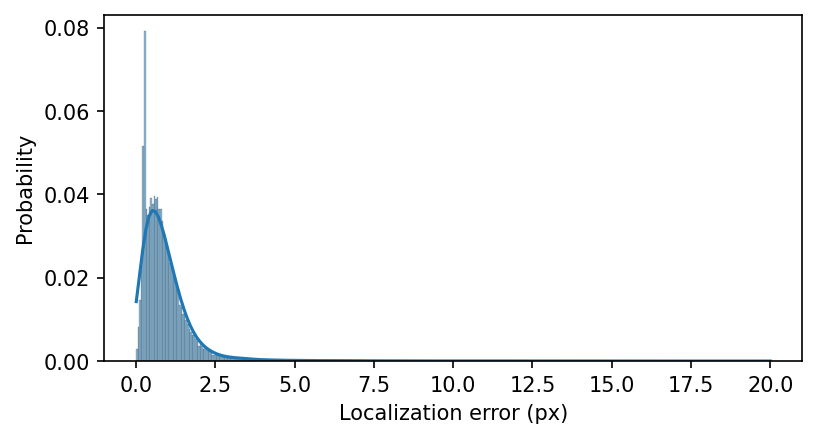

In [9]:
plt.figure(figsize=(6, 3), dpi=150, facecolor="w")
sns.histplot(metrics["distance_metrics"]["dists"].flatten(), binrange=(0, 20), kde=True, kde_kws={"clip": (0, 20)}, stat="probability")
plt.xlabel("Localization error (px)");

This metric is intuitive, but it does not incorporate other sources of error like those stemming from poor instance detection and grouping, or missing points.

The Object Keypoint Similarity (OKS) is a more holistic metric that takes factors such as landmark visibility, animal size, and the difficulty in locating keypoints (all are assumed to be "easy" for our calculations). You can read more about this and other pose estimation metrics in: https://arxiv.org/abs/1707.05388

First let's plot the distribution of OKS scores:

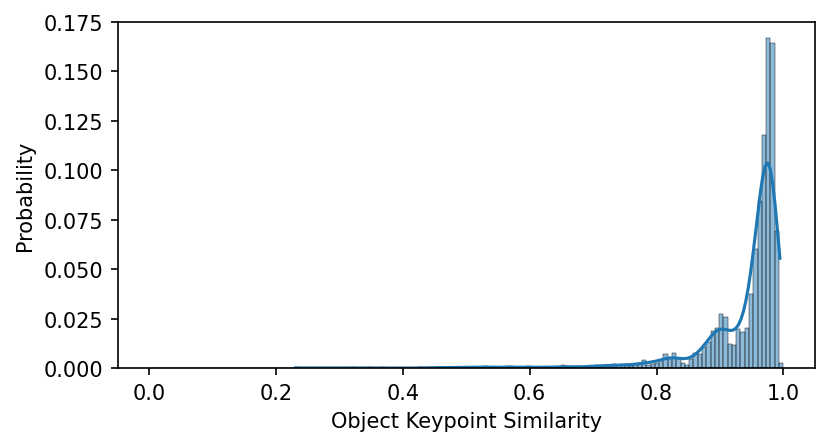

In [12]:
plt.figure(figsize=(6, 3), dpi=150, facecolor="w")
sns.histplot(metrics["voc_metrics"]["oks_voc.match_scores"].flatten(), binrange=(0, 1), kde=True, kde_kws={"clip": (0, 1)}, stat="probability")
plt.xlabel("Object Keypoint Similarity");

Since these range from 0 to 1, it seems like we're doing pretty well!

Another way to summarize this is through precision-recall curves, which evaluate how well the model does at different thresholds of OKS scores. The higher the threshold, the more stringent our criteria for classifying a prediction as correct.

Here we plot this at different thresholds:

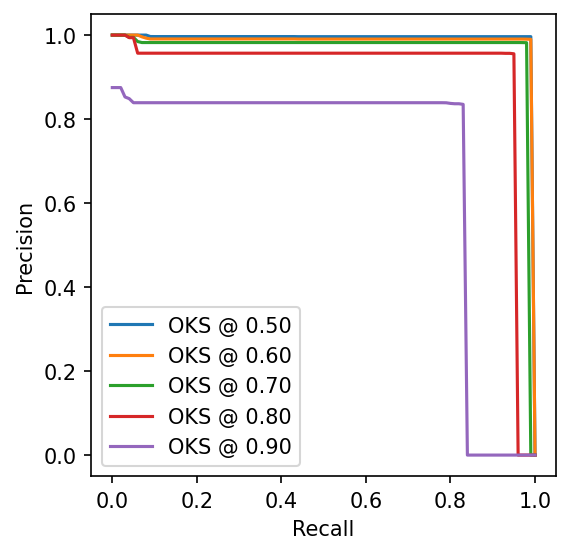

In [14]:
plt.figure(figsize=(4, 4), dpi=150, facecolor="w")
for precision, thresh in zip(metrics["voc_metrics"]['oks_voc.precisions'][::2], metrics["voc_metrics"]["oks_voc.match_score_thresholds"][::2]):
    plt.plot(metrics["voc_metrics"]["oks_voc.recall_thresholds"], precision, "-", label=f"OKS @ {thresh:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left");

An easy way to summarize this analysis is to take the average over all of these thresholds to compute the **mean Average Precision (mAP)** and **mean Average Recall (mAR)** which are widely used in the pose estimation literature.

Here are those values saved out:

In [15]:
print("mAP:", metrics["voc_metrics"]["oks_voc.mAP"])
print("mAR:", metrics["voc_metrics"]["oks_voc.mAR"])

mAP: 0.8763579063082116
mAR: 0.9309687499999999


Great, but what if we have some new labels or want to evaluate the model with an updated set of labels for better comparisons with newer models?

For this, we'll need to generate new predictions.

First, let's download a new SLEAP labels package file (`.pkg.slp`). This is important since it denotes that the labels contain the images as well which we need for predicting.

In [16]:
!wget -q https://storage.googleapis.com/sleap-data/datasets/wt_gold.13pt/tracking_split2/test.pkg.slp

Next we can simply load the model, the ground truth (GT) labels, and generate the predictions (~1 min on CPU):

In [ ]:
from sleap_nn.predict import run_inference
import sleap_io as sio

labels_gt = sio.load_slp("test.pkg.slp")
labels_pr = run_inference(data_path="test.pkg.slp", model_paths=["td_fast.centered_instance.n=1800"])

Generating another set of metrics can then be calculated with the pair of GT and predicted labels:

In [18]:
from sleap_nn.evaluation import Evaluator

evals = Evaluator(labels_gt, labels_pr)

metrics = evals.evaluate()

print("Error distance (50%):", metrics["distance_metrics"]["p50"])
print("Error distance (90%):", metrics["distance_metrics"]["p90"])
print("Error distance (95%):", metrics["distance_metrics"]["p95"])
print("mAP:", metrics["voc_metrics"]["oks_voc.mAP"])
print("mAR:", metrics["voc_metrics"]["oks_voc.mAR"])

Error distance (50%): 0.7671373993864394
Error distance (90%): 1.9559974547904944
Error distance (95%): 2.99784457113545
mAP: 0.8297769329605552
mAR: 0.90175
